In [17]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [18]:
X, y = make_classification(
    n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1
)

In [19]:
df = pd.DataFrame(X, columns=[f"col{x}" for x in range(1, 6)])
df["target"] = y
df.head()

,col1,col2,col3,col4,col5,target
0,-1.687045,-2.010045,0.099692,1.164539,-1.132487,1
1,-0.561390,-0.711844,-0.808059,2.807811,-0.105375,1
2,1.745713,-2.645194,-4.069130,-2.453560,2.829626,0
3,-3.002899,-2.285392,-0.121483,-0.883914,0.890321,1
4,2.376104,0.447349,-2.077881,-1.196952,0.241077,0


##### Helper functions:

In [30]:
import random


def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)


def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1] - 1)))
    return df[cols]


def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [36]:
sample_features(df, 0.8)

,col3,col2,col4,col1
0,0.099692,-2.010045,1.164539,-1.687045
1,-0.808059,-0.711844,2.807811,-0.561390
2,-4.069130,-2.645194,-2.453560,1.745713
3,-0.121483,-2.285392,-0.883914,-3.002899
4,-2.077881,0.447349,-1.196952,2.376104
...,...,...,...,...
95,-0.123492,-0.464004,-0.063536,0.882285
96,-1.015270,-0.990660,-0.325144,1.715680
97,-1.595238,-2.518330,-3.502236,1.076105
98,-1.692437,-2.184616,1.281170,-1.132268


In [21]:
df1 = sample_rows(df, 0.1)
df2 = sample_rows(df, 0.1)
df3 = sample_rows(df, 0.1)

In [22]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [23]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[0] <= -0.343\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

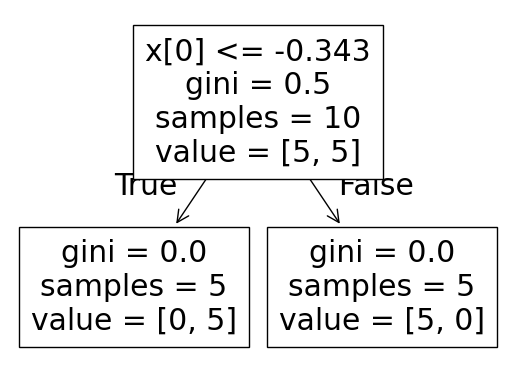

In [24]:
from sklearn.tree import plot_tree

plot_tree(clf1)